In [1]:
import adrienParamClassSheared as params
import adrienUtils as utils
import numpy as np
import matplotlib.pyplot as plt

pList = params.generate()

In [10]:
# Define useful functions 
def load_binary(varName,p):
    
    filePath = p.dirPath + varName + "_" + p.tStamp
    X = np.memmap(filePath, dtype="single", mode="r",shape=(p.Nx+2,p.Ny,p.Nz), order="F")
    return X[:-2,:,:] #Chop off two rows of zeros


def d_periodic_4th(f, dx, axis):
    """Periodic 4th-order central derivative."""
    return (
        -np.roll(f, -2, axis=axis)
        + 8*np.roll(f, -1, axis=axis)
        - 8*np.roll(f,  1, axis=axis)
        + np.roll(f,  2, axis=axis)
    ) / (12.0 * dx)

def compute_chi(p):
    dx = p.Lx / p.Nx
    dy = p.Ly / p.Ny
    dz = p.Lz / p.Nz

    # Load density and form buoyancy
    r = load_binary("r", p)
    b = -p.zAccel * r   # buoyancy

    # Periodic 4th-order gradients
    bx = d_periodic_4th(b, dx, axis=0)
    by = d_periodic_4th(b, dy, axis=1)
    bz = d_periodic_4th(b, dz, axis=2)

    # Diffusivity and background stratification
    D = p.kinV / p.Pr
    N2 = -p.dGrad * p.zAccel

    chi = (D / N2) * (bx**2 + by**2 + bz**2)
    return chi
    
# def compute_chi(p):
    
#     dx = p.Lx/p.Nx
#     dy = p.Ly/p.Ny
#     dz = p.Lz/p.Nz
        
#     #Load in density and compute gradients
#     r = load_binary("r", p)
#     b = -p.zAccel*r # buoyancy
#     bx = np.gradient(b,dx,axis=0)
#     by = np.gradient(b,dy,axis=1)
#     bz = np.gradient(b,dz,axis=2)
#     D = p.kinV/p.Pr
#     N2 = -p.dGrad*p.zAccel
#     chi = (D/N2) * (bx**2+by**2+bz**2)
#     return chi

def compute_eps(p):
    dx = p.Lx / p.Nx
    dy = p.Ly / p.Ny
    dz = p.Lz / p.Nz

    # Load velocities
    u = load_binary("u", p)
    v = load_binary("v", p)
    w = load_binary("w", p)

    # Periodic 4th-order derivatives
    ux = d_periodic_4th(u, dx, axis=0)
    uy = d_periodic_4th(u, dy, axis=1)
    uz = d_periodic_4th(u, dz, axis=2)

    vx = d_periodic_4th(v, dx, axis=0)
    vy = d_periodic_4th(v, dy, axis=1)
    vz = d_periodic_4th(v, dz, axis=2)

    wx = d_periodic_4th(w, dx, axis=0)
    wy = d_periodic_4th(w, dy, axis=1)
    wz = d_periodic_4th(w, dz, axis=2)

    nu = p.kinV
    eps = nu * (
        2*ux**2 + 2*vy**2 + 2*wz**2
        + (uy + vx)**2 + (uz + wx)**2 + (vz + wy)**2
    )
    return eps

# def compute_eps(p):
    
#     dx = p.Lx/p.Nx
#     dy = p.Ly/p.Ny
#     dz = p.Lz/p.Nz
        
#     #Load in density and compute gradients
#     u = load_binary("u", p)
#     v = load_binary("v", p)
#     w = load_binary("w", p)
#     ux = np.gradient(u,dx,axis=0)
#     uy = np.gradient(u,dy,axis=1)
#     uz = np.gradient(u,dz,axis=2)
#     vx = np.gradient(v,dx,axis=0)
#     vy = np.gradient(v,dy,axis=1)
#     vz = np.gradient(v,dz,axis=2)
#     wx = np.gradient(w,dx,axis=0)
#     wy = np.gradient(w,dy,axis=1)
#     wz = np.gradient(w,dz,axis=2)
#     nu = p.kinV
#     eps = nu * ( 2*ux**2 + 2*vy**2 + 2*wz**2 + (uy+vx)**2 + (uz+wx)**2 + (vz+wy)**2 )
#     return eps

def compute_eps_pseudo(p):
    dx = p.Lx / p.Nx
    dy = p.Ly / p.Ny
    dz = p.Lz / p.Nz

    # Load velocities
    u = load_binary("u", p)
    v = load_binary("v", p)
    w = load_binary("w", p)

    # Periodic 4th-order derivatives
    ux = d_periodic_4th(u, dx, axis=0)
    uy = d_periodic_4th(u, dy, axis=1)
    uz = d_periodic_4th(u, dz, axis=2)

    vx = d_periodic_4th(v, dx, axis=0)
    vy = d_periodic_4th(v, dy, axis=1)
    vz = d_periodic_4th(v, dz, axis=2)

    wx = d_periodic_4th(w, dx, axis=0)
    wy = d_periodic_4th(w, dy, axis=1)
    wz = d_periodic_4th(w, dz, axis=2)

    nu = p.kinV
    eps_pseudo = nu * (
        ux**2 + uy**2 + uz**2
        + vx**2 + vy**2 + vz**2
        + wx**2 + wy**2 + wz**2
    )
    return eps_pseudo
    
# def compute_eps_pseudo(p):
    
#     dx = p.Lx/p.Nx
#     dy = p.Ly/p.Ny
#     dz = p.Lz/p.Nz
        
#     #Load in density and compute gradients
#     u = load_binary("u", p)
#     v = load_binary("v", p)
#     w = load_binary("w", p)
#     ux = np.gradient(u,dx,axis=0)
#     uy = np.gradient(u,dy,axis=1)
#     uz = np.gradient(u,dz,axis=2)
#     vx = np.gradient(v,dx,axis=0)
#     vy = np.gradient(v,dy,axis=1)
#     vz = np.gradient(v,dz,axis=2)
#     wx = np.gradient(w,dx,axis=0)
#     wy = np.gradient(w,dy,axis=1)
#     wz = np.gradient(w,dz,axis=2)
#     nu = p.kinV
#     eps_pseudo = nu * ( ux**2 + uy**2 + uz**2 + vx**2 + vy**2 + vz**2 + wx**2 + wy**2 + wz**2)
#     return eps_pseudo
    
from mpl_toolkits.axes_grid1 import make_axes_locatable

def imshow_with_cbar(ax, Z, cmap, vmin, vmax, cbar_label):
    im = ax.imshow(Z.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.5%", pad=0.08)
    cb = ax.figure.colorbar(im, cax=cax)
    cb.set_label(cbar_label)
    return im, cb
    
def set_index_axis(
    ax,
    axis="x",
    N=1,
    label=None,
    nticks=5
):
    """
    Set axis ticks in index space (0 ... N).

    Parameters
    ----------
    ax : matplotlib axis
    axis : 'x' or 'y'
    N : int, number of grid points (Nx, Ny, Nz)
    label : axis label (optional)
    nticks : number of ticks (default 5)
    """
    ticks = np.linspace(0, N, nticks, dtype=int)

    if axis == "x":
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{t}" for t in ticks])
        if label:
            ax.set_xlabel(label)
    elif axis == "y":
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t}" for t in ticks])
        if label:
            ax.set_ylabel(label)
            

def memory_report(globals_dict=None, min_gb=0.05):
    """
    Print a report of NumPy array memory usage and container / node memory.
    
    Parameters
    ----------
    globals_dict : dict
        Namespace to inspect (use globals() from caller)
    min_gb : float
        Minimum array size (GB) to display
    """
    if globals_dict is None:
        globals_dict = globals()

    # ---- NumPy arrays ----
    rows = []
    for name, obj in globals_dict.items():
        if isinstance(obj, np.ndarray):
            size_gb = obj.nbytes / 1024**3
            if size_gb >= min_gb:
                rows.append((name, size_gb, obj.shape, obj.dtype))
    rows.sort(key=lambda x: x[1], reverse=True)

    if rows:
        for name, size_gb, shape, dtype in rows:
            print(f"{name:25s} {size_gb:6.2f} GB  shape={shape}  dtype={dtype}")
    else:
        print("(No NumPy arrays above threshold)")

    # ---- current process usage ----
    process = psutil.Process(os.getpid())
    used_gb = process.memory_info().rss / 1024**3

    # ---- node memory ----
    vm = psutil.virtual_memory()
    node_total_gb = vm.total / 1024**3

    # ---- container (cgroup) limit ----
    def _cgroup_limit_gb():
        paths = [
            "/sys/fs/cgroup/memory.max",              # cgroup v2
            "/sys/fs/cgroup/memory/memory.limit_in_bytes"  # cgroup v1
        ]
        for p in paths:
            if os.path.exists(p):
                with open(p) as f:
                    val = f.read().strip()
                if val.isdigit():
                    return int(val) / 1024**3
        return None

    limit_gb = _cgroup_limit_gb()
    avail_to_me_gb = max(limit_gb - used_gb, 0) if limit_gb else None

    # ---- summary ----
    percent_used = 100 * used_gb / limit_gb if limit_gb else None
    percent_left = 100 * avail_to_me_gb / limit_gb if limit_gb else None
    
    print()
    print(
        f"{'Notebook memory used':25s}: "
        f"{used_gb:6.2f} GB "
        f"({percent_used:5.1f} % )"
    )
    print(
        f"{'Remaining available to me':25s}: "
        f"{avail_to_me_gb:6.2f} GB "
        f"({percent_left:5.1f} % )"
    )
    print(f"{'Container memory limit':25s}: {limit_gb:6.2f} GB")
    print(f"{'Total node memory':25s}: {node_total_gb:6.2f} GB")

from pathlib import Path
from datetime import datetime

def save_slice_figure(
    fig,
    p,
    slice_dir,
    idx,
    outdir="figures",
    fmt="png",
    dpi=300
):
    """
    Save a figure with an automatic, informative filename.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
    p : DatParam
        Simulation parameter object (needs p.name)
    slice_dir : str
        'x', 'y', or 'z'
    idx : int
        Slice index
    outdir : str
        Output directory
    fmt : str
        'png', 'jpg', 'pdf', etc.
    dpi : int
        Resolution (ignored for pdf/svg)
    """
    Path(outdir).mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    fname = (
        f"{p.name}_slice_{slice_dir}{idx}_"
        f"{timestamp}.{fmt}"
    )

    path = Path(outdir) / fname

    fig.savefig(
        path,
        dpi=dpi if fmt.lower() in ["png", "jpg", "jpeg"] else None,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved → {path}")
    return path

In [3]:
# Load in simulation parameters from the parameter list
p = pList["R1P1"]

x = np.linspace(0.0, p.Lx, p.Nx, endpoint=False)
y = np.linspace(0.0, p.Ly, p.Ny, endpoint=False)
z = np.linspace(0.0, p.Lz, p.Nz, endpoint=False)

In [13]:
# Load in actual simulation data  and check size
r = utils.load_binary("r",p)
b = -p.zAccel*r # buoyancy
del r
u = utils.load_binary("u",p)
v = utils.load_binary("v",p)
w = utils.load_binary("w",p)
u.shape

(1536, 768, 384)

In [21]:
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.2)

b                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
u                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
v                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
w                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
chi                         1.69 GB  shape=(1536, 768, 384)  dtype=float32
eps                         1.69 GB  shape=(1536, 768, 384)  dtype=float32

Notebook memory used     :  10.25 GB (  8.0 %)
Remaining available to me: 117.75 GB ( 92.0 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [6]:
eps = utils.compute_eps(p,u,v,w)

In [5]:
chi = utils.compute_chi(p,b)

In [22]:
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.2)

b                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
u                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
v                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
w                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
chi                         1.69 GB  shape=(1536, 768, 384)  dtype=float32
eps                         1.69 GB  shape=(1536, 768, 384)  dtype=float32

Notebook memory used     :  10.25 GB (  8.0 %)
Remaining available to me: 117.75 GB ( 92.0 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [37]:
# Compute average quantities 
eps_avg = np.mean(eps)
chi_avg = np.mean(chi)
Gamma = chi_avg/eps_avg 
N2 = -p.dGrad*p.zAccel
Ri = N2
print(f"<ε> = {eps_avg:.3e}")
print(f"<χ> = {chi_avg:.3e}")
print(f"Ri = {Ri:.3f}")
print(f"Γ = {Gamma:.3f}")
Reb = eps_avg/(p.kinV*N2)
print(f"Reb = {Reb:.1f}")

<ε> = 2.820e-03
<χ> = 5.407e-04
Ri = 0.164
Γ = 0.192
Reb = 34.5


In [23]:
# Compute average energies
Ek = np.mean((u.flatten())**2+(v.flatten())**2+(w.flatten())**2)/2
Ek_pct = 100 * Ek / p.targKE
Ep = np.mean((b.flatten())**2)/(2*N2)
RPK = Ep/Ek

print(f"Measured Ek = {Ek:.3e} ({Ek_pct:.2f}% of target)")
print(f"Measured Ep = {Ep:.3e}")
print(f"RPK = {RPK:.2f}")

Measured Ek = 1.579e-02 (99.97% of target)
Measured Ep = 2.406e-03
RPK = 0.15


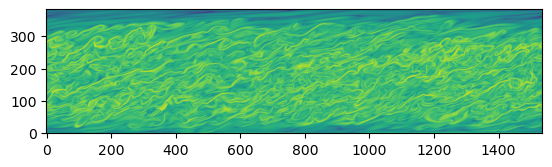

In [38]:
plt.imshow(np.log10(chi[:,512,:].T),origin="lower")

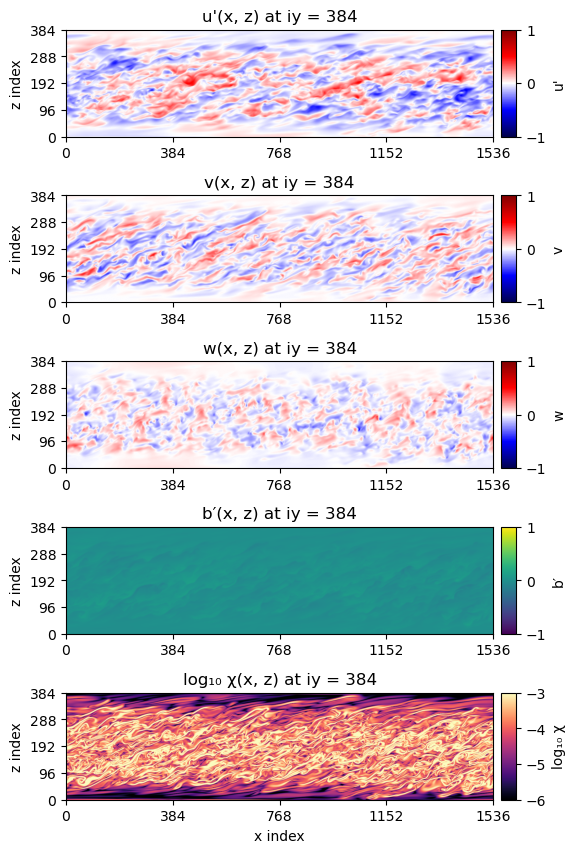

In [28]:
# Plot slices of the perturbations

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 2

fig, axs = plt.subplots(5, 1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.55)

utils.imshow_with_cbar(axs[0], u[:, yIdx, :], "seismic", -1, 1, "u'")
axs[0].set_title(f"u'(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[0], "x", p.Nx, " ")
utils.set_index_axis(axs[0], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[1], v[:, yIdx, :], "seismic", -1, 1, "v")
axs[1].set_title(f"v(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[1], "x", p.Nx, " ")
utils.set_index_axis(axs[1], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[2], w[:, yIdx, :], "seismic", -1, 1, "w")
axs[2].set_title(f"w(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[2], "x", p.Nx, " ")
utils.set_index_axis(axs[2], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[3], b[:, yIdx, :], "viridis", -1, 1, "b′")
axs[3].set_title(f"b′(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[3], "x", p.Nx, " ")
utils.set_index_axis(axs[3], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[4], np.log10(chi[:, yIdx, :]), "magma", -6, -3, "log₁₀ χ")
axs[4].set_title(f"log₁₀ χ(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[4], "x", p.Nx, "x index")
utils.set_index_axis(axs[4], "y", p.Nz, "z index")

In [32]:
utils.save_slice_figure(
    fig,
    p,
    slice_dir="y",
    idx=yIdx,
    outdir="figures",
    fmt="pdf",
    dpi=500
)

Saved -> figures/R1P1_slice_y384_20260130_055319.pdf


PosixPath('figures/R1P1_slice_y384_20260130_055319.pdf')

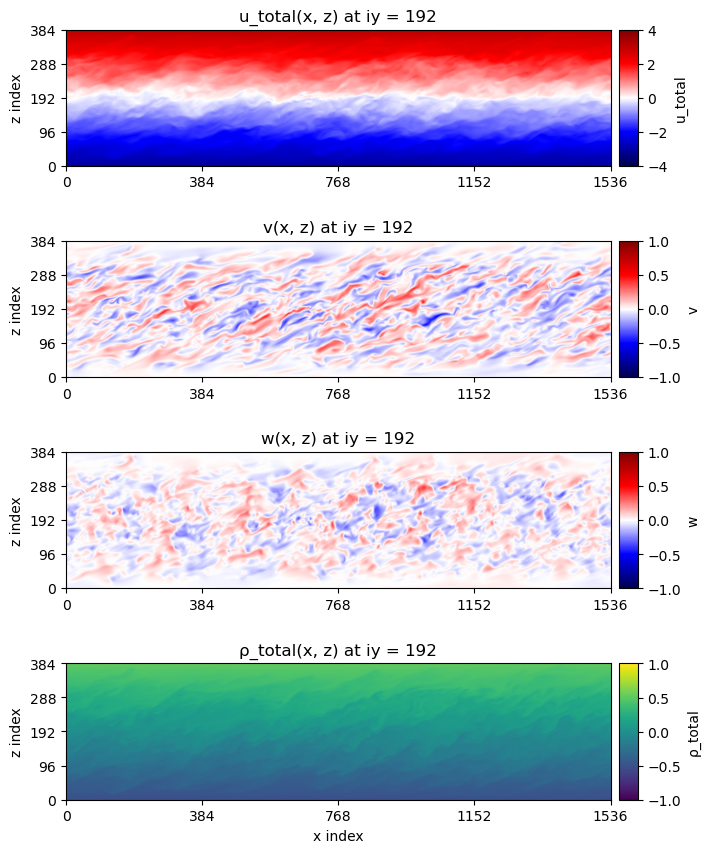

In [48]:
# Plot several slices of the TOTAL fields

# Define background fields U(z) = z and B(z) = N^2 * z = Ri * z
dz = p.Lz/p.Nz
z_centre = (np.arange(p.Nz) - p.Nz/2)*dz # so that z=0 in the middle
Uz = z_centre;
Bz = -p.dGrad * p.zAccel * z_centre # equivalently, N2*z_centre

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 4

fig, axs = plt.subplots(4, 1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.55)

utils.imshow_with_cbar(axs[0], u[:, yIdx, :] + Uz, "seismic", -4, 4, "u_total");  
axs[0].set_title(f"u_total(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[0], "x", p.Nx, " ")
utils.set_index_axis(axs[0], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[1], v[:, yIdx, :], "seismic", -1, 1, "v"); 
axs[1].set_title(f"v(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[1], "x", p.Nx, " ")
utils.set_index_axis(axs[1], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[2], w[:, yIdx, :], "seismic", -1, 1, "w");  
axs[2].set_title(f"w(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[2], "x", p.Nx, " ")
utils.set_index_axis(axs[2], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[3], b[:, yIdx, :] + Bz, "viridis", -1, 1, "ρ_total");  
axs[3].set_title(f"ρ_total(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[3], "x", p.Nx, " ")
utils.set_index_axis(axs[3], "y", p.Nz, "z index")
utils.set_index_axis(axs[3], "x", p.Nx, "x index")

In [49]:
utils.save_slice_figure(
    fig,
    p,
    slice_dir="y",
    idx=yIdx,
    outdir="figures",
    fmt="jpg",
    dpi=300
)

Saved -> figures/R1P1_slice_y192_20260130_060948.jpg


PosixPath('figures/R1P1_slice_y192_20260130_060948.jpg')

In [47]:
print("u_total min:", np.min(u[:, yIdx, :] + Uz))
print("u_total max:", np.max(u[:, yIdx, :] + Uz))
print("b_total min:", np.min(b[:, yIdx, :] + Rz))
print("b_total max:", np.max(b[:, yIdx, :] + Rz))

u_total min: -3.188535438972064
u_total max: 3.17161171754767
b_total min: -0.13814914039178877
b_total max: 0.12932929297954673
